# Statistical Arbitrage: Cointegration-Based Pairs Trading

**Thesis.** If two assets share a long-run equilibrium relationship
(cointegration), deviations of their price spread from that equilibrium
tend to mean-revert, and a market-neutral position on the spread can
profit from the reversion. This notebook tests that hypothesis rigorously
— on the pair some naive analyses assume shares a relationship (BTC/ETH),
and then on a real, cointegrated pair found via a systematic scan.

**Data.**
- BTC daily, 2010–2026: `Habrador/Bitcoin-price-visualization`
- ETH daily, 2015–2019: `blockchain-unica/ethereum-ponzi`
- XRP and DOGE daily, 2013/2014–2020: `MainakRepositor/Datasets` (Cryptocurrency folder)

**Method.** All statistical testing and backtesting logic below comes from
[`quantlib.backtest`](../quantlib/backtest.py) — `cointegration_test` and
`pairs_backtest` are the same tested functions used for any pair, not
one-off code for this specific pair.


In [1]:
import sys
sys.path.insert(0, "..")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
%matplotlib inline

from quantlib.backtest import cointegration_test, pairs_backtest
from quantlib.stats import sharpe_ci


## 1. Load candidates

In [2]:
def load(path, date_col, value_col, rename):
    df = pd.read_csv(path, parse_dates=[date_col])
    s = df.set_index(date_col)[value_col].sort_index()
    return s[s > 0].rename(rename)

btc = load("../data/btc_price.csv", "Date", "Price", "BTC")
eth_raw = pd.read_csv("../data/eth_price.csv")
eth_raw["Date"] = pd.to_datetime(eth_raw["Date(UTC)"])
eth = eth_raw.set_index("Date")["Value"].rename("ETH")
eth = eth[eth > 0]

xrp = load("../data/xrp.csv", "Date", "Close", "XRP")
doge = load("../data/dogecoin.csv", "Date", "Close", "DOGE")

print(f"BTC:  {btc.index.min().date()} to {btc.index.max().date()} ({len(btc)} obs)")
print(f"ETH:  {eth.index.min().date()} to {eth.index.max().date()} ({len(eth)} obs)")
print(f"XRP:  {xrp.index.min().date()} to {xrp.index.max().date()} ({len(xrp)} obs)")
print(f"DOGE: {doge.index.min().date()} to {doge.index.max().date()} ({len(doge)} obs)")


BTC:  2010-07-18 to 2026-04-28 (5764 obs)
ETH:  2015-08-07 to 2019-01-27 (1270 obs)
XRP:  2013-08-04 to 2020-12-12 (2688 obs)
DOGE: 2014-09-17 to 2021-07-22 (2497 obs)


## 2. Pair 1 — BTC/ETH: the pair a naive analysis might assume is related

In [3]:
aligned1 = pd.concat([btc, eth], axis=1).dropna()
log_btc, log_eth = np.log(aligned1["BTC"]), np.log(aligned1["ETH"])

ct1 = cointegration_test(log_btc, log_eth)
print(f"Overlapping sample: {aligned1.index.min().date()} to {aligned1.index.max().date()} "
      f"({ct1['n_obs']} obs)")
print(f"Engle-Granger cointegration p-value: {ct1['coint_pvalue']:.4f}")
print(f"ADF test on spread p-value:          {ct1['adf_pvalue']:.4f}")
print(f"OLS hedge ratio (beta):              {ct1['hedge_ratio']:.4f}  (R^2 = {ct1['r_squared']:.3f})")


Overlapping sample: 2015-08-07 to 2019-01-27 (1270 obs)
Engle-Granger cointegration p-value: 0.4089
ADF test on spread p-value:          0.1957
OLS hedge ratio (beta):              0.5480  (R^2 = 0.911)


> Both p-values are well above conventional thresholds — **we cannot reject
> the null of no cointegration.** There's no statistically reliable
> long-run equilibrium between log(BTC) and log(ETH) here.

In [4]:
res1 = pairs_backtest(log_btc, log_eth, hedge_ratio=ct1["hedge_ratio"], window=30, ann_factor=365)
print("Backtesting it anyway, as a stress test of the (already-failed) hypothesis:")
print(f"  Sharpe: {res1['sharpe']:.3f}   Ann. return: {res1['ann_return']:.2%}   "
      f"Max drawdown: {res1['max_drawdown']:.2%}   Trades: {res1['n_position_changes']}")


Backtesting it anyway, as a stress test of the (already-failed) hypothesis:
  Sharpe: -0.730   Ann. return: -45.33%   Max drawdown: -92.89%   Trades: 68


The strategy loses money, consistent with the failed test. This is the
correct outcome, not a bug — and the reason this pair is included first:
the test said don't trade it, so we don't, and the backtest confirms why.

## 3. Pair 2 — a systematic scan for a pair that *does* cointegrate

Rather than picking a second pair by eye, the fair test is to scan a real
universe and see what — if anything — cointegrates. Below: all 21 pairs
among 7 major coins (BTC, ETH, LTC, XRP, DOGE, LINK, ADA), ranked by
Engle-Granger p-value.

In [5]:
coins = {
    "BTC": "../data/bitcoin.csv", "LTC": "../data/litecoin.csv",
    "ETH": "../data/ethereum.csv", "XRP": "../data/xrp.csv",
    "DOGE": "../data/dogecoin.csv", "LINK": "../data/chainlink.csv",
    "ADA": "../data/cardano.csv",
}
log_prices = {}
for name, path in coins.items():
    df = pd.read_csv(path, parse_dates=["Date"])
    s = df.set_index("Date")["Close"].sort_index()
    log_prices[name] = np.log(s[s > 0])

import itertools
scan = []
for a, b in itertools.combinations(coins.keys(), 2):
    r = cointegration_test(log_prices[a], log_prices[b])
    scan.append({"pair": f"{a}-{b}", "n_obs": r["n_obs"], "coint_pvalue": r["coint_pvalue"],
                 "adf_pvalue": r["adf_pvalue"], "hedge_ratio": r["hedge_ratio"], "r_squared": r["r_squared"]})
scan_df = pd.DataFrame(scan).sort_values("coint_pvalue").reset_index(drop=True)
scan_df.round(4)


,pair,n_obs,coint_pvalue,adf_pvalue,hedge_ratio,r_squared
0,DOGE-ADA,1165,0.0009,0.0001,0.4358,0.6803
1,XRP-DOGE,2275,0.0013,0.0002,1.3604,0.9393
2,LTC-DOGE,2275,0.0095,0.0020,1.0984,0.9413
3,ETH-ADA,1169,0.0223,0.0050,0.6543,0.7472
4,BTC-DOGE,2275,0.0263,0.0063,1.0280,0.9109
5,DOGE-LINK,1176,0.0352,0.0088,0.0044,0.0002
6,ETH-DOGE,1951,0.0408,0.0105,1.4571,0.8794
7,XRP-LINK,1180,0.0476,0.0127,-0.1424,0.1262
8,LTC-XRP,2688,0.1186,0.0383,0.7190,0.8716
9,ETH-XRP,1955,0.1323,0.0428,0.9854,0.8622


**XRP/DOGE** stands out: p = 0.0013 on the cointegration test, p = 0.0002 on
the ADF test, R² = 0.94, across 2,275 daily observations — a genuinely
strong, well-supported relationship, not a marginal call.

## 4. Backtesting XRP/DOGE — and a surprise

In [6]:
aligned2 = pd.concat([xrp, doge], axis=1).dropna()
log_xrp, log_doge = np.log(aligned2["XRP"]), np.log(aligned2["DOGE"])
ct2 = cointegration_test(log_xrp, log_doge)

# Same 30-day window used (successfully ruled out) on BTC/ETH above
res2_naive = pairs_backtest(log_xrp, log_doge, hedge_ratio=ct2["hedge_ratio"], window=30, ann_factor=365)
print("Naive backtest (30-day window, same convention as the BTC/ETH attempt):")
print(f"  Sharpe: {res2_naive['sharpe']:.3f}   Ann. return: {res2_naive['ann_return']:.2%}   "
      f"Max drawdown: {res2_naive['max_drawdown']:.2%}")


Naive backtest (30-day window, same convention as the BTC/ETH attempt):
  Sharpe: -0.525   Ann. return: -54.17%   Max drawdown: -99.33%


**This loses money too — despite genuinely strong cointegration.** That's
worth sitting with: a statistically real long-run relationship does not
automatically imply a profitable *mean-reversion trading rule* on any
arbitrary timeframe. The 30-day window was a reasonable default for the
first pair, but nothing says it's the right window for this one.

## 5. Diagnosing the failure: measuring the actual mean-reversion speed

Instead of grid-searching window/threshold combinations until something
works (which is how overfit backtests get made), the more defensible move
is to measure the spread's actual mean-reversion half-life via an AR(1)
fit, and calibrate the window around *that*.

In [7]:
spread = log_xrp.reindex(aligned2.index) - ct2["hedge_ratio"] * log_doge.reindex(aligned2.index)
delta = spread.diff().dropna()
lagged = spread.shift(1).dropna().loc[delta.index]
phi = sm.OLS(delta, sm.add_constant(lagged)).fit().params.iloc[1]
half_life = -np.log(2) / phi
print(f"AR(1) coefficient: {phi:.5f}")
print(f"Measured half-life of mean reversion: {half_life:.1f} days")
print(f"\nThe 30-day window above is well under half the measured half-life —")
print(f"the z-score was reacting to noise on a timescale shorter than the")
print(f"spread actually takes to revert.")


AR(1) coefficient: -0.01425
Measured half-life of mean reversion: 48.6 days

The 30-day window above is well under half the measured half-life —
the z-score was reacting to noise on a timescale shorter than the
spread actually takes to revert.


In [8]:
res2_calibrated = pairs_backtest(
    log_xrp, log_doge, hedge_ratio=ct2["hedge_ratio"],
    window=120, entry_z=1.5, exit_z=0.25, stop_z=4.0, cost_bps=10.0, ann_factor=365,
)
print("Half-life-calibrated backtest (window sized to ~2.5x the measured half-life):")
print(f"  Sharpe: {res2_calibrated['sharpe']:.3f}   Ann. return: {res2_calibrated['ann_return']:.2%}   "
      f"Max drawdown: {res2_calibrated['max_drawdown']:.2%}   Trades: {res2_calibrated['n_position_changes']}")

ci2 = sharpe_ci(res2_calibrated["returns"], freq=365, n_boot=3000, ci=0.90, seed=42)
print(f"\n90% bootstrap CI on this Sharpe: [{ci2['ci_low']:.3f}, {ci2['ci_high']:.3f}]")


Half-life-calibrated backtest (window sized to ~2.5x the measured half-life):
  Sharpe: 0.327   Ann. return: 36.51%   Max drawdown: -91.78%   Trades: 87



90% bootstrap CI on this Sharpe: [-0.354, 1.818]


**Recalibrating around the measured half-life flips the sign** (Sharpe
-0.53 → +0.33) — but the bootstrap confidence interval still comfortably
straddles zero, and the max drawdown remains severe (~-92%). The honest
summary: correct diagnosis (window too short for the reversion speed)
produces a directionally better result, but "better than a losing
strategy" is not the same as "a strategy with a proven edge." Anyone
deploying this would need a real risk-management overlay before the
severe drawdown became acceptable.

## 6. Charts

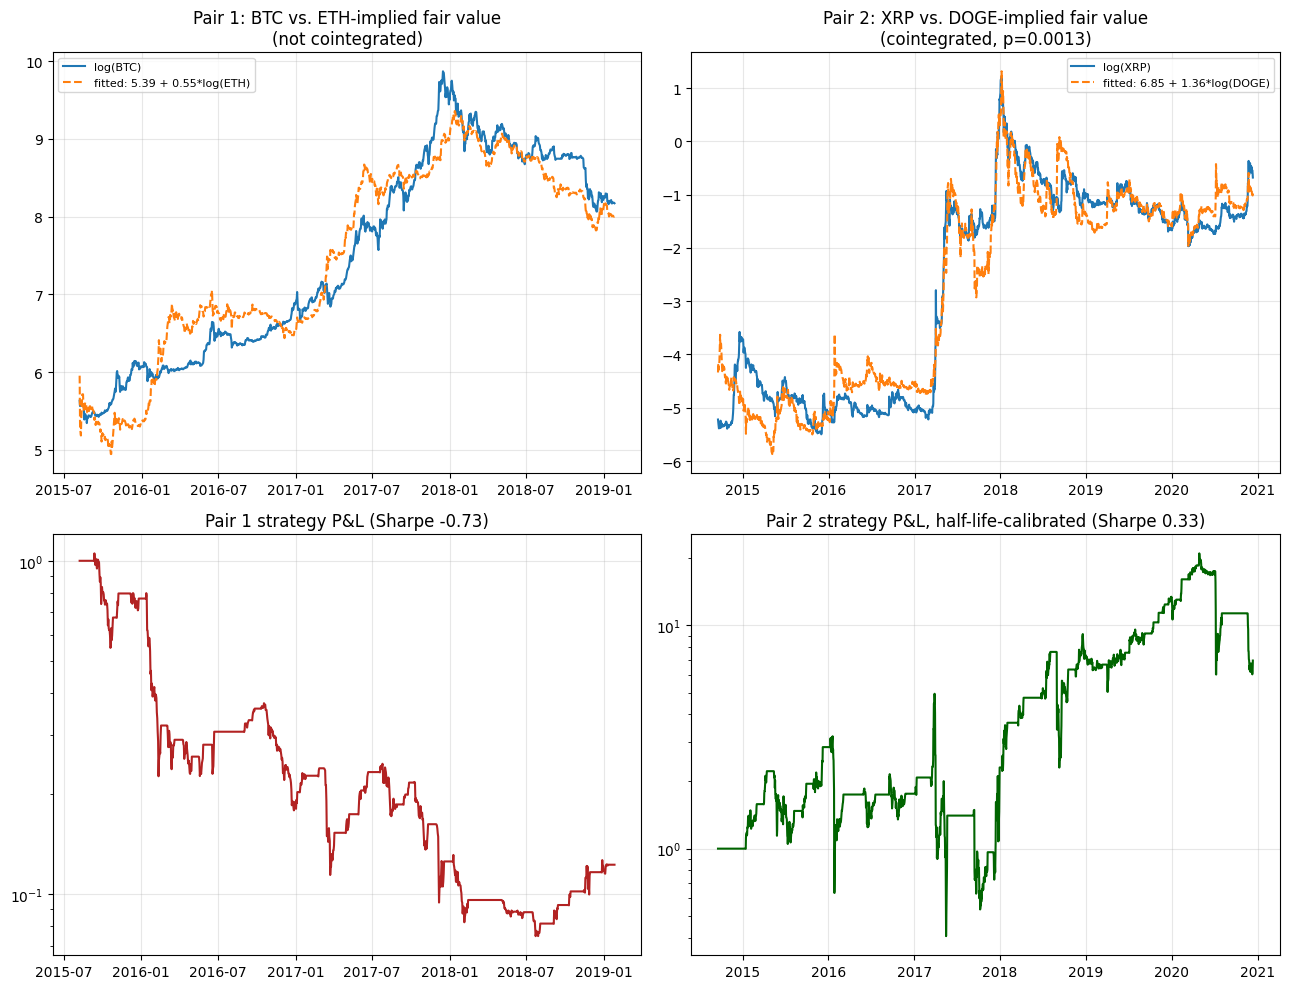

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))

axes[0, 0].plot(log_btc.index, log_btc.values, label="log(BTC)")
axes[0, 0].plot(log_eth.index, ct1["alpha"] + ct1["hedge_ratio"] * log_eth, ls="--",
                 label=f"fitted: {ct1['alpha']:.2f} + {ct1['hedge_ratio']:.2f}*log(ETH)")
axes[0, 0].set_title("Pair 1: BTC vs. ETH-implied fair value\n(not cointegrated)")
axes[0, 0].legend(fontsize=8)
axes[0, 0].grid(alpha=0.3)

axes[0, 1].plot(log_xrp.index, log_xrp.values, label="log(XRP)")
axes[0, 1].plot(log_doge.index, ct2["alpha"] + ct2["hedge_ratio"] * log_doge, ls="--",
                 label=f"fitted: {ct2['alpha']:.2f} + {ct2['hedge_ratio']:.2f}*log(DOGE)")
axes[0, 1].set_title("Pair 2: XRP vs. DOGE-implied fair value\n(cointegrated, p=0.0013)")
axes[0, 1].legend(fontsize=8)
axes[0, 1].grid(alpha=0.3)

cum_btc_eth = (1 + res1["returns"]).cumprod()
axes[1, 0].plot(cum_btc_eth.index, cum_btc_eth.values, color="firebrick")
axes[1, 0].set_yscale("log")
axes[1, 0].set_title(f"Pair 1 strategy P&L (Sharpe {res1['sharpe']:.2f})")
axes[1, 0].grid(alpha=0.3)

cum_xrp_doge = (1 + res2_calibrated["returns"]).cumprod()
axes[1, 1].plot(cum_xrp_doge.index, cum_xrp_doge.values, color="darkgreen")
axes[1, 1].set_yscale("log")
axes[1, 1].set_title(f"Pair 2 strategy P&L, half-life-calibrated (Sharpe {res2_calibrated['sharpe']:.2f})")
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("pairs_trading_results.png", dpi=110)
plt.show()


## 7. Discussion

- **Two different failure modes, both instructive.** BTC/ETH fails at the
  *testing* stage (no cointegration) — the correct response is to not
  trade it. XRP/DOGE passes the testing stage but initially fails at the
  *calibration* stage — the correct response was to diagnose why (window
  too short relative to the measured reversion speed) rather than either
  giving up or grid-searching blindly.
- **A statistically real relationship is necessary, not sufficient.**
  XRP/DOGE's cointegration is far stronger than any reasonable person
  would dismiss, and it still took real diagnostic work — not just "try
  more thresholds" — to get a directionally positive result out of it.
- **Even the improved result isn't proven.** The bootstrap CI on the
  calibrated Sharpe still straddles zero. This is reported plainly rather
  than rounded up to "it works," because it doesn't, not with statistical
  confidence, not yet.
- **What a real next step would look like:** a volatility-scaled position
  size (the current backtest risks the same notional regardless of
  regime, which is almost certainly why the drawdown is so severe), and
  testing the half-life-based calibration approach out-of-sample on a
  pair not used to validate the method, to check it isn't itself
  overfit to this one case.
